In [56]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

#matplotlib 한글

# 사용할 한글 폰트 지정 - 자기 OS만 # 지우고 쓰기
# font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # macOS
# font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # Linux

font_prop = fm.FontProperties(fname=font_path)

# 폰트 적용
plt.rc('font', family=font_prop.get_name())

train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')
sample_submission = pd.read_csv('csv/sample_submission.csv')

#특성과 타겟 변수 분리
train = train.drop(columns=['ID'], axis = 1)
test = test.drop(columns=['ID'], axis = 1)


In [57]:
# 설립연도 -> 2025-설립연도
train['설립연도'] =2025- train['설립연도']
test['설립연도'] =2025- test['설립연도']

# 기업가치 매핑
ev_map={'1500-2500':2,'2500-3500':3,'3500-4500':4,'4500-6000':5.25,'6000이상':6.5}
train['기업가치(백억원)']=train['기업가치(백억원)'].map(ev_map)
# 투자단계 매핑
round_map={'Seed':1,'Series A':2, 'Series B':3, 'Series C':4, 'IPO':5}
train['투자단계']=train['투자단계'].map(round_map)

category_features = ['국가','분야','투자단계']
numeric_features = ['설립연도','직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)','기업가치(백억원)']
bool_features = ['인수여부','상장여부']

# OneHotEncoder 객체를 각 범주형 feature별로 따로 저장하여 사용
encoders = {}

# 범주형 데이터를 encoding
for feature in ['국가','분야']:
    encoders[feature] = OneHotEncoder(sparse_output=False)
    train[feature] = train[feature].fillna('Missing')
    test[feature] = test[feature].fillna('Missing')
    encoded = encoders[feature].fit_transform(train[[feature]])
    encoded_df = pd.DataFrame(encoded, columns=encoders[feature].get_feature_names_out([feature]))
    train=pd.concat([train.drop(columns=feature).reset_index(drop=True),encoded_df],axis=1)
    
    encoded = encoders[feature].transform(test[[feature]])
    encoded_df = pd.DataFrame(encoded, columns=encoders[feature].get_feature_names_out([feature]))
    test=pd.concat([test.drop(columns=feature).reset_index(drop=True),encoded_df],axis=1)

# 불리언 값을 0과 1로 변환 ('Yes' → 1, 'No' → 0 으로 변환)
bool_map = {'Yes': 1, 'No': 0}

for feature in bool_features:
    train[feature] = train[feature].map(bool_map)
    test[feature] = test[feature].map(bool_map)

# 수치형 변수 결측치를 평균값으로 대체
for feature in numeric_features:
    mean_value = train[feature].mean()
    train[feature] = train[feature].fillna(mean_value)
    test[feature] = test[feature].fillna(mean_value)
    


In [58]:
numeric_features=['설립연도','직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)']
bool_features = ['인수여부','상장여부']
onehot_features=list(set(train.columns)-set(numeric_features)-set(bool_features)-{'성공확률','투자단계'})


In [59]:
train[onehot_features]=train[onehot_features].astype(int)

In [22]:
#num 로그, 제곱, 역수
temp_dict={}
log1p_features=[]
reciprocal_features=[]
sqrt_features=[]
for feature in numeric_features:
    temp_dict[feature+'**2']=train[feature]**2
    temp_dict['log1p'+feature]=np.log1p(train[feature])
    temp_dict['log1p'+feature+'**2']=(np.log1p(train[feature]))**2
    log1p_features.append('log1p'+feature)
    temp_dict['1/('+feature+'+1)']=1/(train[feature]+1)
    reciprocal_features.append('1/('+feature+'+1)')
    temp_dict['sqrt('+feature+')']=np.sqrt(train[feature])
    sqrt_features.append('sqrt('+feature+')')
temp_df = pd.DataFrame(temp_dict)
train = pd.concat([train, temp_df], axis=1)

#2차항
temp_dict={}
new_numeric_features=numeric_features+log1p_features+reciprocal_features
for i in range(len(new_numeric_features)):
    for j in range(i+1,len(new_numeric_features)):
        temp_dict[new_numeric_features[i]+'*'+new_numeric_features[j]]=train[new_numeric_features[i]]*train[new_numeric_features[j]]

temp_df = pd.DataFrame(temp_dict)
train = pd.concat([train, temp_df], axis=1)

In [23]:
#~A, ~B, A&B, ~A&B,A&~B,~A&~B
temp_dict={}
for bool_feature in bool_features:
    temp_dict['~'+bool_feature]=train[bool_feature]^1
for onehot_feature in onehot_features:
    temp_dict['~'+onehot_feature]=train[onehot_feature]^1

for bool_feature in bool_features:
    for onehot_feature in onehot_features:
        temp_dict[bool_feature+'&'+onehot_feature]=train[bool_feature]&train[onehot_feature]
        temp_dict['~'+bool_feature+'&'+onehot_feature]=(train[bool_feature]^1)&train[onehot_feature]
        temp_dict[bool_feature+'&~'+onehot_feature]=train[bool_feature]&(train[onehot_feature]^1)
        temp_dict['~'+bool_feature+'&~'+onehot_feature]=(train[bool_feature]^1)&(train[onehot_feature]^1)

temp_df = pd.DataFrame(temp_dict)
train = pd.concat([train, temp_df], axis=1)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# X: features, y: soft labels (확률 값)
X_train, X_test, y_train, y_test = train_test_split(train.drop(columns='성공확률',axis=1), train['성공확률'], test_size=0.2, random_state=42)

# 회귀 모델 예시
model = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8
)
model.fit(X_train, y_train)

print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))

y_pred = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.871173560147187
test score: -0.02333363122378973
train MSE: 0.00753846590003403
test MSE: 0.059143799360819205


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# X: features, y: soft labels (확률 값)

# 회귀 모델 예시
model2 = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model2.fit(X_train, y_train)

print("train score:",model2.score(X_train, y_train))
print("test score:",model2.score(X_test,y_test))

y_pred = model2.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model2.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.5922763455604223
test score: -0.03031745130231056
train MSE: 0.02385854075562192
test MSE: 0.05954743082654377


In [26]:
model3 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8
)
model3.fit(X_train, y_train)

print("train score:",model3.score(X_train, y_train))
print("test score:",model3.score(X_test,y_test))

y_pred = model3.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model3.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.6371434663059329
test score: -0.016544588327968235
train MSE: 0.021233076137029846
test MSE: 0.05875142508655414


In [27]:
model4 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model4.fit(X_train, y_train)

print("train score:",model4.score(X_train, y_train))
print("test score:",model4.score(X_test,y_test))

y_pred = model4.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model4.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.3695664305284033
test score: -0.023094334022884855
train MSE: 0.03689073431764631
test MSE: 0.059129969124808106


In [28]:
model5 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8
)
model5.fit(X_train, y_train)

print("train score:",model5.score(X_train, y_train))
print("test score:",model5.score(X_test,y_test))

y_pred = model5.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model5.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.4691451095647522
test score: -0.010181613811532708
train MSE: 0.031063743545071933
test MSE: 0.05838367553092973


In [29]:
model6 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model6.fit(X_train, y_train)

print("train score:",model6.score(X_train, y_train))
print("test score:",model6.score(X_test,y_test))

y_pred = model6.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model6.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.2518245222413654
test score: -0.012122827372636369
train MSE: 0.04378057278280039
test MSE: 0.058495868409059924


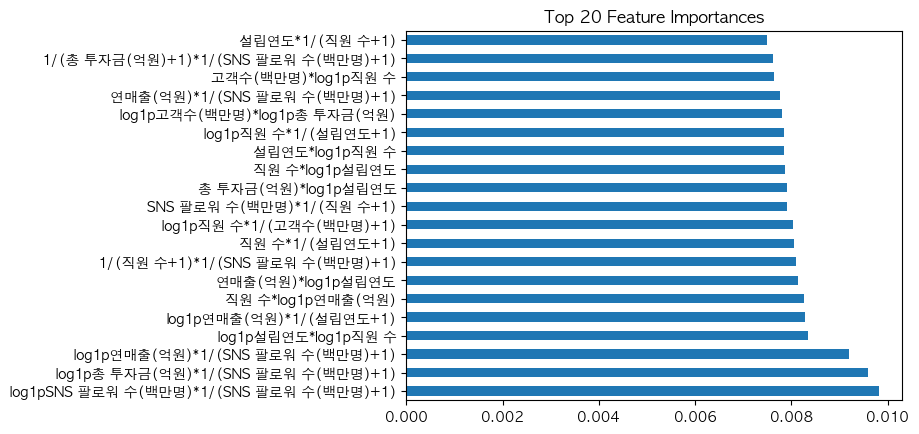

In [30]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

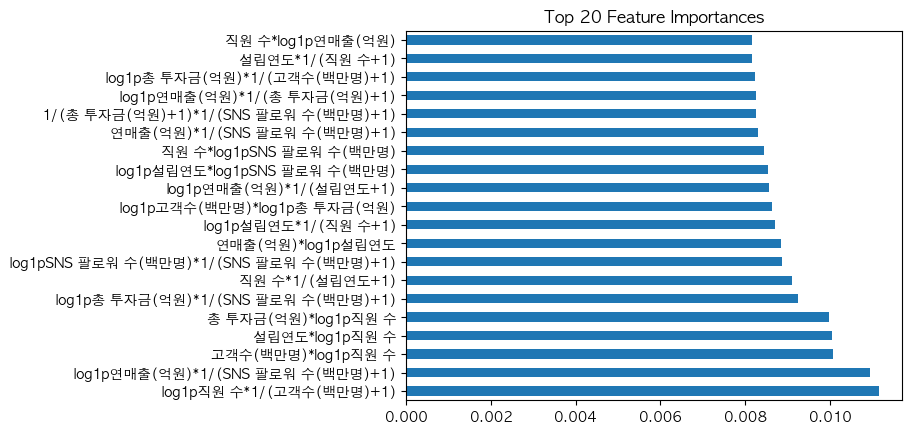

In [31]:
feat_imp = pd.Series(model2.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

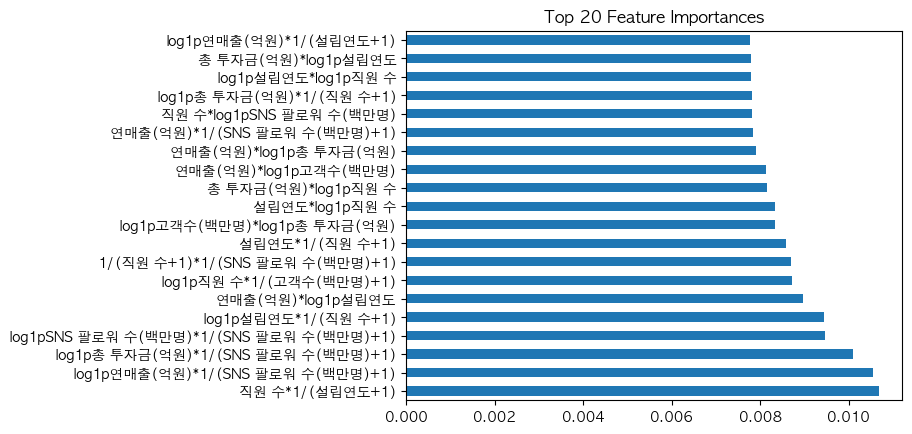

In [32]:
feat_imp = pd.Series(model3.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

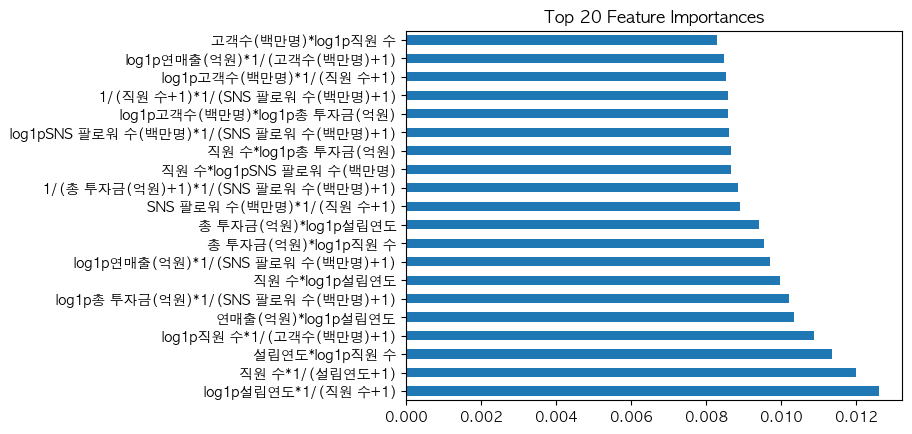

In [33]:
feat_imp = pd.Series(model4.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

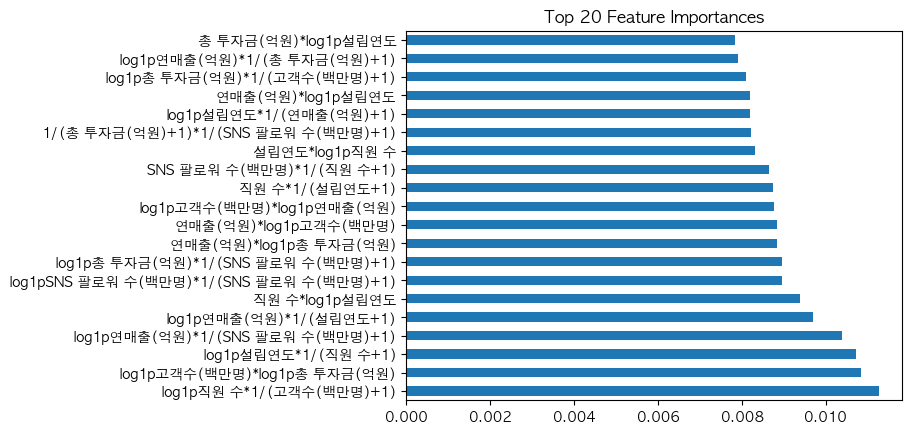

In [34]:
feat_imp = pd.Series(model5.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

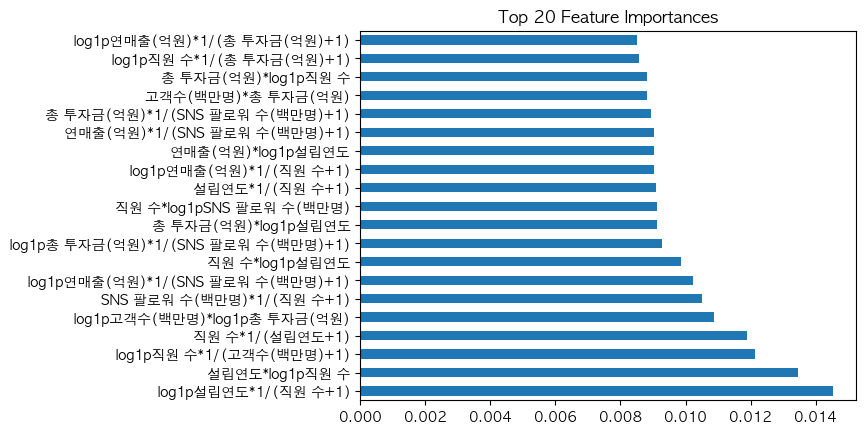

In [35]:
feat_imp = pd.Series(model6.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()